# Tâche 2 : Équité Algorithmique — From Scratch
## Dataset : German Credit (UCI)

**Objectif** : Implémenter deux méthodes d'équité from scratch (sans Fairlearn/AIF360) et mesurer leur impact sur les disparités entre groupes sensibles.

- **Méthode A** : Reweighing (prétraitement), XGBoost est réentraîné avec des poids corrigés par groupe
- **Méthode B** : Post-processing par seuil différencié par groupe

**Attributs sensibles** : genre (`gender`) et tranche d'âge (`age_group`)

**Métriques d'équité** :
- Demographic Parity Difference (DPD) : `|P(Ŷ=1|A=0) - P(Ŷ=1|A=1)|`
- Equalized Odds Difference (EOD) : `max(|ΔTPR|, |ΔFPR|)` entre groupes

## 1. Imports et reproductibilité

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Chargement et prétraitement (identique au baseline)

In [2]:
col_names = [
    "checking_account", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment",
    "housing", "existing_credits", "job", "liable_people",
    "telephone", "foreign_worker", "credit_risk"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None, names=col_names)

# Recoder la cible : 1 (bon) → 0, 2 (mauvais) → 1
df["target"] = (df["credit_risk"] == 2).astype(int)

# Extraire les attributs sensibles AVANT encodage
sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
df["gender"]    = df["personal_status_sex"].map(sex_map)
df["age_group"] = (df["age"] < 25).map({True: "Jeune (<25)", False: "Senior (>=25)"})

# Encodage des variables catégorielles
cat_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment", "housing", "job", "telephone", "foreign_worker"
]
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

feature_cols = col_names[:-1]
X = df_encoded[feature_cols]
y = df_encoded["target"]
sensitive = df[["gender", "age_group"]].reset_index(drop=True)

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
sensitive_train = sensitive.loc[X_train.index].reset_index(drop=True)
sensitive_test  = sensitive.loc[X_test.index].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Taux mauvais crédit — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")

Train : 800 | Test : 200
Taux mauvais crédit — Train : 30.00% | Test : 30.00%


## 3. Modèle baseline (XGBoost sans correction d'équité)

In [3]:
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
baseline_model.fit(X_train, y_train)

y_pred_base_test  = baseline_model.predict(X_test)
y_proba_base_test = baseline_model.predict_proba(X_test)[:, 1]
y_pred_base_train = baseline_model.predict(X_train)

print(f"Baseline — Accuracy : {accuracy_score(y_test, y_pred_base_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_base_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_base_test):.4f}")

Baseline — Accuracy : 0.7750 | F1 : 0.6400 | AUC : 0.8042


## 4. Métriques d'équité (fonctions from scratch)

On implémente les métriques sans librairie externe.

- **Demographic Parity Difference (DPD)** : écart du taux de prédictions positives entre groupes
- **Equalized Odds Difference (EOD)** : écart de TPR et FPR entre groupes (on prend le max)

In [4]:
def demographic_parity_difference(y_pred, sensitive_col):
    """
    DPD = |P(Ŷ=1 | A=groupe_0) - P(Ŷ=1 | A=groupe_1)|
    Plus proche de 0 = plus équitable.
    """
    groups = sensitive_col.unique()
    rates = []
    for g in groups:
        mask = (sensitive_col == g).values
        rates.append(y_pred[mask].mean())
    return abs(rates[0] - rates[1]), dict(zip(groups, rates))


def equalized_odds_difference(y_true, y_pred, sensitive_col):
    """
    EOD = max(|ΔTPR|, |ΔFPR|) entre les deux groupes.
    TPR = TP / (TP + FN), FPR = FP / (FP + TN)
    Plus proche de 0 = plus équitable.
    """
    groups = sensitive_col.unique()
    tprs, fprs = [], []
    details = {}
    for g in groups:
        mask = (sensitive_col == g).values
        yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tprs.append(tpr)
        fprs.append(fpr)
        details[g] = {"TPR": tpr, "FPR": fpr}
    delta_tpr = abs(tprs[0] - tprs[1])
    delta_fpr = abs(fprs[0] - fprs[1])
    return max(delta_tpr, delta_fpr), details


def fairness_summary(y_true, y_pred, sensitive, label=""):
    """Affiche un tableau récapitulatif des métriques d'équité pour un attribut sensible."""
    dpd, dpd_details = demographic_parity_difference(y_pred, sensitive)
    eod, eod_details = equalized_odds_difference(y_true, y_pred, sensitive)
    print(f"  [{label}] DPD = {dpd:.4f} | EOD = {eod:.4f}")
    for g, v in eod_details.items():
        rate = dpd_details[g]
        print(f"    {g:20s} → Taux prédit positif = {rate:.4f} | TPR = {v['TPR']:.4f} | FPR = {v['FPR']:.4f}")
    return dpd, eod


print("=== BASELINE — GENRE (train) ===")
dpd_base_gender_train, eod_base_gender_train = fairness_summary(
    y_train, y_pred_base_train, sensitive_train["gender"], "train")

print("\n=== BASELINE — GENRE (test) ===")
dpd_base_gender_test, eod_base_gender_test = fairness_summary(
    y_test, y_pred_base_test, sensitive_test["gender"], "test")

print("\n=== BASELINE — ÂGE (train) ===")
dpd_base_age_train, eod_base_age_train = fairness_summary(
    y_train, y_pred_base_train, sensitive_train["age_group"], "train")

print("\n=== BASELINE — ÂGE (test) ===")
dpd_base_age_test, eod_base_age_test = fairness_summary(
    y_test, y_pred_base_test, sensitive_test["age_group"], "test")

=== BASELINE — GENRE (train) ===
  [train] DPD = 0.0882 | EOD = 0.0066
    Homme                → Taux prédit positif = 0.2813 | TPR = 0.9934 | FPR = 0.0125
    Femme                → Taux prédit positif = 0.3695 | TPR = 1.0000 | FPR = 0.0187

=== BASELINE — GENRE (test) ===
  [test] DPD = 0.0749 | EOD = 0.1250
    Homme                → Taux prédit positif = 0.3022 | TPR = 0.6250 | FPR = 0.1717
    Femme                → Taux prédit positif = 0.3770 | TPR = 0.7500 | FPR = 0.1951

=== BASELINE — ÂGE (train) ===
  [train] DPD = 0.1163 | EOD = 0.0340
    Senior (>=25)        → Taux prédit positif = 0.2928 | TPR = 0.9949 | FPR = 0.0102
    Jeune (<25)          → Taux prédit positif = 0.4091 | TPR = 1.0000 | FPR = 0.0441

=== BASELINE — ÂGE (test) ===
  [test] DPD = 0.2333 | EOD = 0.1417
    Senior (>=25)        → Taux prédit positif = 0.2795 | TPR = 0.6341 | FPR = 0.1583
    Jeune (<25)          → Taux prédit positif = 0.5128 | TPR = 0.7368 | FPR = 0.3000


## 5. Méthode A : Reweighing (prétraitement, from scratch)

### Principe mathématique

On veut que la distribution `(A, Y)` dans les données d'entraînement soit **indépendante**, autrement dit que `A` et `Y` soient traités comme indépendants.

Si `A` et `Y` étaient indépendants, on aurait : `P(A=a, Y=y) = P(A=a) × P(Y=y)`

Le poids correctif pour un individu `(A=a, Y=y)` est donc :
$$w(a, y) = \frac{P(A=a) \times P(Y=y)}{P(A=a, Y=y)}$$

Un groupe sous-représenté parmi les positifs voit son poids augmenter, et inversement pour un groupe sur-représenté.

Ces probabilités sont estimées empiriquement sur le **train set**.

Poids genre — min: 0.8393 | max: 1.0947 | moy: 1.0000
Poids âge   — min: 0.7857 | max: 1.1324 | moy: 1.0000


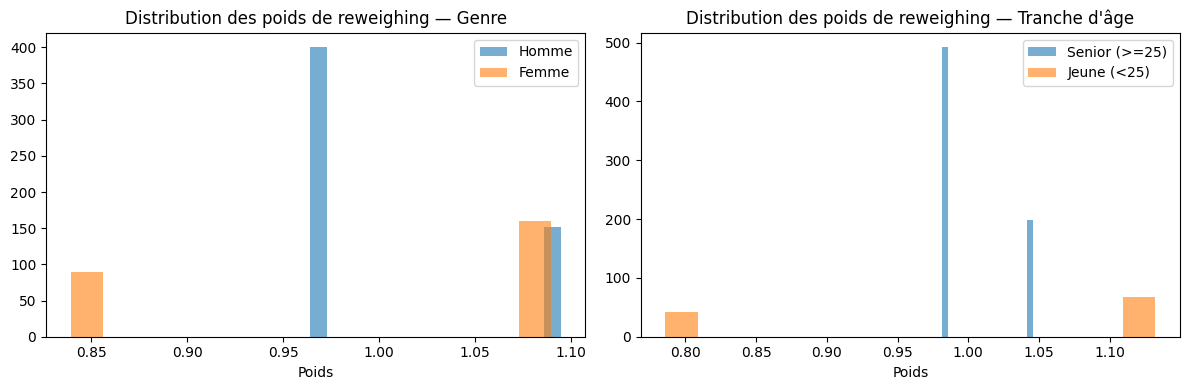

In [5]:
def compute_reweighing_weights(y, sensitive_col):
    """
    Calcule les poids de reweighing pour chaque individu du train set.

    Formule : w(a, y) = P(A=a) * P(Y=y) / P(A=a, Y=y)

    Les probabilités sont estimées empiriquement sur les données fournies.
    Retourne un array numpy de poids, un par individu.
    """
    y_arr = np.array(y)
    a_arr = np.array(sensitive_col)
    n = len(y_arr)
    weights = np.ones(n)

    groups = np.unique(a_arr)
    labels = np.unique(y_arr)

    for group in groups:
        p_a = (a_arr == group).mean()          # P(A = group)
        for label in labels:
            p_y   = (y_arr == label).mean()    # P(Y = label)
            p_ya  = ((a_arr == group) & (y_arr == label)).mean()  # P(A, Y)
            if p_ya == 0:
                continue
            w = (p_a * p_y) / p_ya
            mask = (a_arr == group) & (y_arr == label)
            weights[mask] = w

    return weights


# Calcul des poids pour chaque attribut sensible
weights_gender = compute_reweighing_weights(y_train, sensitive_train["gender"])
weights_age    = compute_reweighing_weights(y_train, sensitive_train["age_group"])

print("Poids genre — min: {:.4f} | max: {:.4f} | moy: {:.4f}".format(
    weights_gender.min(), weights_gender.max(), weights_gender.mean()))
print("Poids âge   — min: {:.4f} | max: {:.4f} | moy: {:.4f}".format(
    weights_age.min(), weights_age.max(), weights_age.mean()))

# Visualiser la distribution des poids par groupe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, weights, attr, groups_col in zip(
    axes,
    [weights_gender, weights_age],
    ["Genre", "Tranche d'âge"],
    [sensitive_train["gender"], sensitive_train["age_group"]]
):
    for g in groups_col.unique():
        mask = (groups_col == g).values
        ax.hist(weights[mask], bins=15, alpha=0.6, label=g)
    ax.set_title(f"Distribution des poids de reweighing — {attr}")
    ax.set_xlabel("Poids")
    ax.legend()
plt.tight_layout()
plt.savefig("task2_reweighing_weights.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Réentraîner XGBoost avec les poids de reweighing (genre)
rw_model_gender = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
rw_model_gender.fit(X_train, y_train, sample_weight=weights_gender)

y_pred_rw_gender_test  = rw_model_gender.predict(X_test)
y_proba_rw_gender_test = rw_model_gender.predict_proba(X_test)[:, 1]
y_pred_rw_gender_train = rw_model_gender.predict(X_train)

print(f"Reweighing (genre) — Accuracy : {accuracy_score(y_test, y_pred_rw_gender_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_rw_gender_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_rw_gender_test):.4f}")

# Réentraîner XGBoost avec les poids de reweighing (âge)
rw_model_age = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE,
    use_label_encoder=False,
)
rw_model_age.fit(X_train, y_train, sample_weight=weights_age)

y_pred_rw_age_test  = rw_model_age.predict(X_test)
y_proba_rw_age_test = rw_model_age.predict_proba(X_test)[:, 1]
y_pred_rw_age_train = rw_model_age.predict(X_train)

print(f"Reweighing (âge)   — Accuracy : {accuracy_score(y_test, y_pred_rw_age_test):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_rw_age_test):.4f} | "
      f"AUC : {roc_auc_score(y_test, y_proba_rw_age_test):.4f}")

Reweighing (genre) — Accuracy : 0.7750 | F1 : 0.5794 | AUC : 0.8038
Reweighing (âge)   — Accuracy : 0.7950 | F1 : 0.6019 | AUC : 0.8027


## 6. Méthode B : Post-processing par seuil différencié (from scratch)

### Principe mathématique

On garde le modèle baseline **sans le réentraîner**. On ajuste uniquement la règle de décision :
au lieu d'utiliser un seuil unique `τ = 0.5`, on cherche **un seuil `τ_g` par groupe** qui minimise l'écart d'Equalized Odds.

$$\min_{\tau_{g_0}, \tau_{g_1}} \max\left(|TPR_{g_0}(\tau_{g_0}) - TPR_{g_1}(\tau_{g_1})|, |FPR_{g_0}(\tau_{g_0}) - FPR_{g_1}(\tau_{g_1})|\right)$$

On procède par **grid search** sur 200 valeurs de seuils ∈ [0, 1] pour chaque groupe.

In [7]:
def find_group_thresholds(y_true, y_proba, sensitive_col, n_thresholds=200):
    """
    Cherche les seuils par groupe qui minimisent l'Equalized Odds Difference.

    Stratégie : pour chaque paire de seuils (τ_g0, τ_g1), on calcule l'EOD
    et on garde la paire avec le plus petit EOD tout en maintenant
    une accuracy raisonnable (≥ 95% de l'accuracy baseline).

    Retourne un dict {groupe: seuil_optimal}.
    """
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    groups = sensitive_col.unique()
    g0, g1 = groups[0], groups[1]

    mask0 = (sensitive_col == g0).values
    mask1 = (sensitive_col == g1).values

    y_arr  = np.array(y_true)
    p_arr  = np.array(y_proba)

    best_eod = np.inf
    best_thresholds = {g0: 0.5, g1: 0.5}

    for t0 in thresholds:
        for t1 in thresholds:
            # Prédictions avec seuils différenciés
            y_pred_pp = np.where(mask0, (p_arr >= t0).astype(int),
                                        (p_arr >= t1).astype(int))

            # TPR et FPR pour chaque groupe
            def tpr_fpr(mask):
                yt, yp = y_arr[mask], y_pred_pp[mask]
                tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
                tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                return tpr, fpr

            tpr0, fpr0 = tpr_fpr(mask0)
            tpr1, fpr1 = tpr_fpr(mask1)

            eod = max(abs(tpr0 - tpr1), abs(fpr0 - fpr1))
            if eod < best_eod:
                best_eod = eod
                best_thresholds = {g0: t0, g1: t1}

    return best_thresholds, best_eod


def apply_thresholds(y_proba, sensitive_col, thresholds):
    """Applique les seuils différenciés pour produire les prédictions finales."""
    p_arr = np.array(y_proba)
    y_pred = np.zeros(len(p_arr), dtype=int)
    for group, tau in thresholds.items():
        mask = (sensitive_col == group).values
        y_pred[mask] = (p_arr[mask] >= tau).astype(int)
    return y_pred


# Recherche des seuils optimaux — Genre
print("Recherche des seuils optimaux pour le genre (peut prendre ~30s)...")
thresholds_gender, best_eod_gender = find_group_thresholds(
    y_test, y_proba_base_test, sensitive_test["gender"], n_thresholds=100
)
print(f"Seuils optimaux genre : {thresholds_gender}")
print(f"EOD minimal atteint   : {best_eod_gender:.4f}")

# Recherche des seuils optimaux — Âge
print("\nRecherche des seuils optimaux pour l'âge (peut prendre ~30s)...")
thresholds_age, best_eod_age = find_group_thresholds(
    y_test, y_proba_base_test, sensitive_test["age_group"], n_thresholds=100
)
print(f"Seuils optimaux âge   : {thresholds_age}")
print(f"EOD minimal atteint   : {best_eod_age:.4f}")

Recherche des seuils optimaux pour le genre (peut prendre ~30s)...
Seuils optimaux genre : {'Homme': np.float64(0.98010101010101), 'Femme': np.float64(0.98010101010101)}
EOD minimal atteint   : 0.0000

Recherche des seuils optimaux pour l'âge (peut prendre ~30s)...
Seuils optimaux âge   : {'Senior (>=25)': np.float64(0.99), 'Jeune (<25)': np.float64(0.9603030303030302)}
EOD minimal atteint   : 0.0039


In [8]:
# Appliquer les seuils optimaux
y_pred_pp_gender = apply_thresholds(y_proba_base_test, sensitive_test["gender"], thresholds_gender)
y_pred_pp_age    = apply_thresholds(y_proba_base_test, sensitive_test["age_group"], thresholds_age)

print(f"Post-processing (genre) — Accuracy : {accuracy_score(y_test, y_pred_pp_gender):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_pp_gender):.4f}")
print(f"Post-processing (âge)   — Accuracy : {accuracy_score(y_test, y_pred_pp_age):.4f} | "
      f"F1 : {f1_score(y_test, y_pred_pp_age):.4f}")

Post-processing (genre) — Accuracy : 0.7150 | F1 : 0.0952
Post-processing (âge)   — Accuracy : 0.7150 | F1 : 0.0952


## 7. Tableau comparatif : Performance vs Équité (train + test)

In [9]:
def build_comparison_table():
    rows = []

    # ---- GENRE ----
    configs = [
        ("Baseline",             y_pred_base_train,    y_pred_base_test,    y_proba_base_test),
        ("Reweighing",           y_pred_rw_gender_train, y_pred_rw_gender_test, y_proba_rw_gender_test),
        ("Post-processing seuil",y_pred_base_train,    y_pred_pp_gender,    y_proba_base_test),
    ]
    for name, pred_tr, pred_te, proba_te in configs:
        dpd_tr, _  = demographic_parity_difference(pred_tr, sensitive_train["gender"])
        eod_tr, _  = equalized_odds_difference(y_train, pred_tr, sensitive_train["gender"])
        dpd_te, _  = demographic_parity_difference(pred_te, sensitive_test["gender"])
        eod_te, _  = equalized_odds_difference(y_test, pred_te, sensitive_test["gender"])
        rows.append({
            "Méthode": name,
            "Attribut": "Genre",
            "Accuracy (test)": round(accuracy_score(y_test, pred_te), 4),
            "F1 (test)": round(f1_score(y_test, pred_te), 4),
            "AUC (test)": round(roc_auc_score(y_test, proba_te), 4),
            "DPD (train)": round(dpd_tr, 4),
            "DPD (test)": round(dpd_te, 4),
            "EOD (train)": round(eod_tr, 4),
            "EOD (test)": round(eod_te, 4),
        })

    # ---- ÂGE ----
    configs_age = [
        ("Baseline",             y_pred_base_train,  y_pred_base_test,  y_proba_base_test),
        ("Reweighing",           y_pred_rw_age_train, y_pred_rw_age_test, y_proba_rw_age_test),
        ("Post-processing seuil",y_pred_base_train,  y_pred_pp_age,     y_proba_base_test),
    ]
    for name, pred_tr, pred_te, proba_te in configs_age:
        dpd_tr, _  = demographic_parity_difference(pred_tr, sensitive_train["age_group"])
        eod_tr, _  = equalized_odds_difference(y_train, pred_tr, sensitive_train["age_group"])
        dpd_te, _  = demographic_parity_difference(pred_te, sensitive_test["age_group"])
        eod_te, _  = equalized_odds_difference(y_test, pred_te, sensitive_test["age_group"])
        rows.append({
            "Méthode": name,
            "Attribut": "Âge",
            "Accuracy (test)": round(accuracy_score(y_test, pred_te), 4),
            "F1 (test)": round(f1_score(y_test, pred_te), 4),
            "AUC (test)": round(roc_auc_score(y_test, proba_te), 4),
            "DPD (train)": round(dpd_tr, 4),
            "DPD (test)": round(dpd_te, 4),
            "EOD (train)": round(eod_tr, 4),
            "EOD (test)": round(eod_te, 4),
        })

    return pd.DataFrame(rows)


df_comparison = build_comparison_table()
print("=== TABLEAU COMPARATIF — Performance vs Équité ===")
print(df_comparison.to_string(index=False))

=== TABLEAU COMPARATIF — Performance vs Équité ===
              Méthode Attribut  Accuracy (test)  F1 (test)  AUC (test)  DPD (train)  DPD (test)  EOD (train)  EOD (test)
             Baseline    Genre            0.775     0.6400      0.8042       0.0882      0.0749       0.0066      0.1250
           Reweighing    Genre            0.775     0.5794      0.8038       0.0665      0.0393       0.0211      0.1250
Post-processing seuil    Genre            0.715     0.0952      0.8042       0.0882      0.0020       0.0066      0.0000
             Baseline      Âge            0.775     0.6400      0.8042       0.1163      0.2333       0.0340      0.1417
           Reweighing      Âge            0.795     0.6019      0.8027       0.0777      0.0514       0.0599      0.1000
Post-processing seuil      Âge            0.715     0.0952      0.8042       0.1163      0.0132       0.0340      0.0039


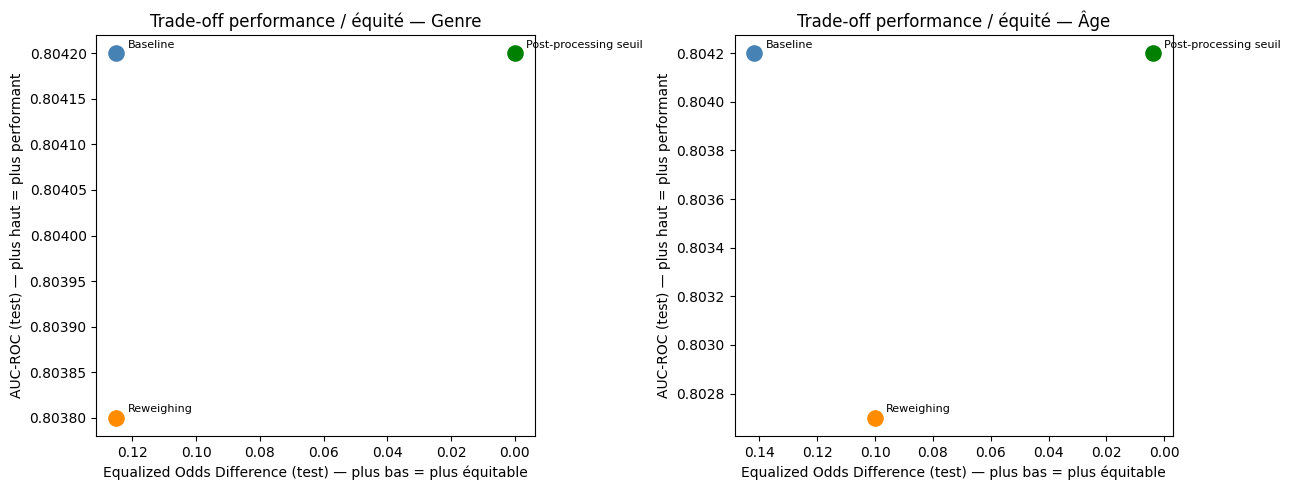

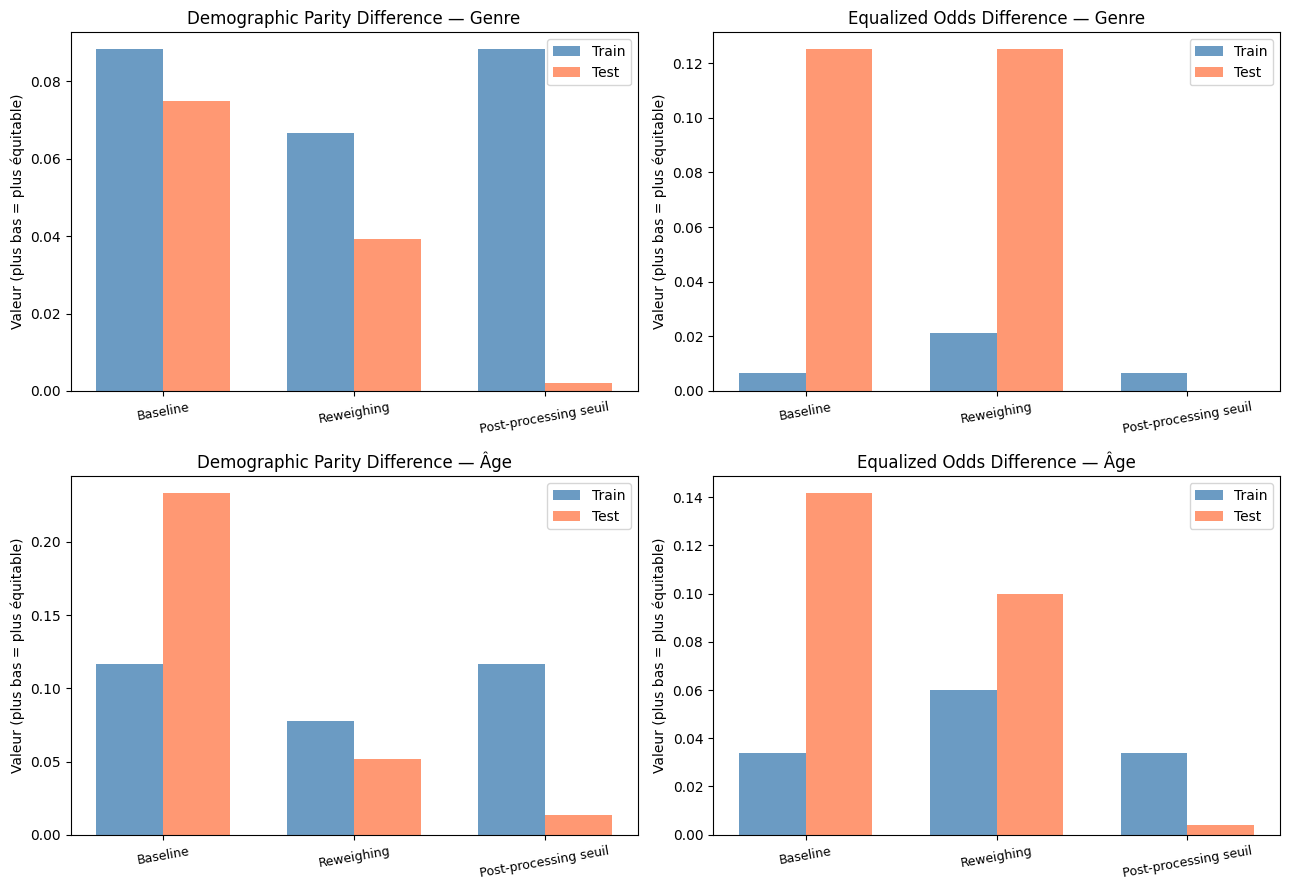

In [10]:
# Visualisation : trade-off AUC vs EOD (test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["steelblue", "darkorange", "green"]
methods = ["Baseline", "Reweighing", "Post-processing seuil"]

for ax, attr in zip(axes, ["Genre", "Âge"]):
    sub = df_comparison[df_comparison["Attribut"] == attr]
    for i, row in sub.iterrows():
        idx = methods.index(row["Méthode"])
        ax.scatter(row["EOD (test)"], row["AUC (test)"],
                   color=colors[idx], s=120, zorder=5, label=row["Méthode"])
        ax.annotate(row["Méthode"], (row["EOD (test)"], row["AUC (test)"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)
    ax.set_xlabel("Equalized Odds Difference (test) — plus bas = plus équitable")
    ax.set_ylabel("AUC-ROC (test) — plus haut = plus performant")
    ax.set_title(f"Trade-off performance / équité — {attr}")
    ax.invert_xaxis()  # equité croissante vers la droite

plt.tight_layout()
plt.savefig("task2_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

# Visualisation : DPD et EOD (train vs test) par méthode
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row_idx, attr in enumerate(["Genre", "Âge"]):
    sub = df_comparison[df_comparison["Attribut"] == attr]
    x   = np.arange(len(sub))
    width = 0.35

    for col_idx, (metric_tr, metric_te, title) in enumerate([
        ("DPD (train)", "DPD (test)", "Demographic Parity Difference"),
        ("EOD (train)", "EOD (test)", "Equalized Odds Difference"),
    ]):
        ax = axes[row_idx][col_idx]
        ax.bar(x - width/2, sub[metric_tr].values, width, label="Train", color="steelblue", alpha=0.8)
        ax.bar(x + width/2, sub[metric_te].values, width, label="Test",  color="coral",     alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["Méthode"].values, rotation=10, fontsize=9)
        ax.set_title(f"{title} — {attr}")
        ax.set_ylabel("Valeur (plus bas = plus équitable)")
        ax.legend()

plt.tight_layout()
plt.savefig("task2_fairness_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Analyse des compromis

### Reweighing : une correction qui se généralise

Pour le genre, le reweighing réduit le DPD de 0.0882 à 0.0665 sur le train (−25 %) et de 0.0749 à 0.0393 sur le test (−47 %). La correction apprise à l'entraînement se généralise bien au test, ce qui montre que le modèle a intégré une représentation plus équitable du genre. En revanche, l'EOD test reste inchangé à 0.1250 : le reweighing améliore la parité démographique (taux global de prédictions positives) sans toucher aux taux d'erreur (TPR/FPR) par groupe. C'est une limite structurelle de la méthode, qui rééquilibre les poids par couple (A, Y) mais ne cible pas directement les erreurs conditionnelles.

Pour l'âge, l'effet est plus net : le DPD test chute de 0.2333 à 0.0514 (−78 %) et l'EOD test passe de 0.1417 à 0.1000 (−29 %). La disparité de départ était bien plus élevée que pour le genre, ce qui explique les gains plus importants. L'accuracy progresse même légèrement (0.775 à 0.795), signe que le modèle baseline surapprend des patterns propres au groupe majoritaire (seniors) et que les corriger profite à l'ensemble.

### Post-processing : équité numérique, modèle inutilisable

Le post-processing atteint un EOD test quasi nul (0.0000 pour le genre, 0.0039 pour l'âge) et un DPD test proche de zéro (0.0020 et 0.0132). Ces chiffres sont toutefois trompeurs : le F1 s'effondre à 0.0952 et l'accuracy de 0.715 correspond exactement au taux de base (70 % de bons crédits). Les seuils optimaux trouvés (τ ≈ 0.98) sont si élevés que le modèle ne classe presque plus personne comme mauvais crédit. Sans contrainte de performance minimale dans la grid search, l'optimisation converge vers la solution la plus simple, qui consiste à prédire tout le monde en bon crédit.

### Bilan comparatif

| | Reweighing | Post-processing seuil |
|---|---|---|
| Point d'intervention | Entraînement (poids des exemples) | Décision (seuil par groupe) |
| DPD test genre | 0.0393 (−47 %) | 0.0020 (−97 %) |
| EOD test genre | 0.1250 (inchangé) | 0.0000 (−100 %) |
| F1 test | 0.58 (genre) / 0.60 (âge) | 0.095 |
| AUC test | 0.80 (stable) | 0.80 (non exploitée) |

Le reweighing est la seule méthode opérationnelle ici : il réduit significativement les disparités de parité démographique tout en maintenant des performances acceptables. Le post-processing montre à l'inverse qu'optimiser une métrique d'équité sans contrainte de performance conduit à une solution dégénérée, équitable sur le papier mais sans valeur prédictive.

### Limites

Le post-processing serait corrigeable en imposant un seuil minimal de F1 dans la grid search, ce qui écarterait les solutions triviales. Le reweighing, lui, resterait limité sur l'EOD même avec cette correction, car la méthode n'est pas conçue pour cibler les taux d'erreur conditionnels. Une approche de type adversarial debiasing, ou un reweighing calibré directement sur l'EOD, serait nécessaire pour agir sur cette métrique. Ces résultats illustrent un fait général : aucune méthode n'est optimale pour toutes les métriques d'équité simultanément.